Implement an unmixing network using several views of the HSI and forwarding them to a feature fusion upsampling method

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

# torch.manual_seed(0)
# torch.cuda.manual_seed(0)

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm
from src.models import unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/ids/edabier/miniconda3/envs/hsu/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.mod

Using device: cuda:0


In [2]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
# Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [3]:
dofa, Y_init_fm, _ = rsfm.create_fm("DOFA", Y_init_n, size="large", version="v1", path=global_path)
# specaware, _, _ = rsfm.create_fm("SpecAware", Y_init_n, path=global_path)

_, features_dofa = rsfm.extract_f(dofa, Y_init_n, 224, wavelengths)
# _, features_specaware = rsfm.extract_f(specaware, Y_init_n, 224, wavelengths)

D_dofa = int(features_dofa.shape[0])
alpha_dofa = int(features_dofa.shape[1]**0.5)
# D_specaware = int(features_specaware.shape[0])
# alpha_specaware = int(features_specaware.shape[1]**0.5)

# D = D_dofa + D_specaware

# plots.plot_pca_features(features_dofa)
# plots.plot_pca_features(features_specaware)

In [4]:
unmixer = unmx.UnmixingFromFeatures(D=D_dofa, B=B, c=c, H=224, alpha=alpha_dofa, upsampler="Features_fusion_grouped", n_features=9)
print(sum(p.numel() for p in unmixer.parameters() if p.requires_grad)/1e6) 

1.844514


In [5]:
def extract_f(fm, Y, D, n_f=4):
    patch = 224//alpha_dofa
    padding = ((n_f-1)*patch)//2

    Y_padded = F.pad(Y, pad=(padding, padding, padding, padding), mode="reflect")
    features = torch.zeros((n_f**2)*D, alpha_dofa, alpha_dofa, device=dev)

    for idx_i, i in enumerate(range(0, 2*padding+1, patch)):
        for idx_j, j in enumerate(range(0, 2*padding+1, patch)):
            Y_crop = Y_padded[:, :, i:i+224, j:j+224]
            Y_crop = Y_crop.to(dev)
            _, f = rsfm.extract_f(fm, Y_crop, 224, wavelengths)

            f = utils.oneD_to_2d(f)
            n = idx_j + ((2*padding)//patch+1)*idx_i
            features[n*D:n*D+D, :, :] = f

        
    return features

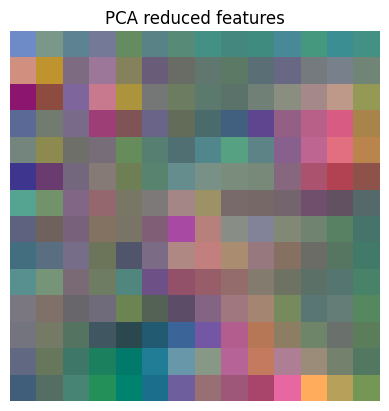

In [10]:
f = extract_f(dofa, Y_init, D_dofa, n_f=2)
plots.plot_pca_features(f)

In [6]:
n_xp = 10
n_f = 1
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, 224, 224)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, n_f**2*D_dofa, 224, 224)
downsample = nn.AdaptiveAvgPool2d((alpha_dofa, alpha_dofa))

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D_dofa, alpha=alpha_dofa, H=224, B=B, c=c, upsampler="Features_fusion_grouped", n_features=n_f**2)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_fm/Y_init_fm.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)

            features = extract_f(dofa, Y, D=D_dofa, n_f=n_f).flatten(1)
            Y_fm = rsfm.reshape_Y("DOFA", Y, 224)

            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, features_hr= utils.oneD_to_2d(model.upsample(features)), features_lr=utils.oneD_to_2d(features))#, channel_selector=model.channel_selector)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():
        features = extract_f(dofa, Y, D=D_dofa, n_f=n_f).flatten(1)
        Y_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y, 224, A_init)
        E_hat, A_hat, _ = model(features, Y_fm)
        upsampled_features[i] = model.upsample(utils.oneD_to_2d(features).unsqueeze(0), Y_fm)[0]
        # upsampled_features[i] = utils.oneD_to_2d(model.upsample(features))
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.upsample.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

plt.show()
plots.plot_pca_features(upsampled_features[0].flatten(1))

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.280, NMSE = 0.323
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.275, NMSE = 0.240
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.278, NMSE = 0.309
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


KeyboardInterrupt: 